In [10]:
from segment_anything import SamPredictor, sam_model_registry, SamAutomaticMaskGenerator
from pathlib import Path
from PIL import Image
from matplotlib import pyplot as plt
import cv2
import numpy as np
import torch

from karyo_wise.config import RAW_DATA_DIR_IMG, SAM_WEIGHTS, RAW_DATA_DIR_ANN
from karyo_wise.plots import show_anns
from karyo_wise.dataset import parse_voc_xml_to_bounding_box

%matplotlib inline

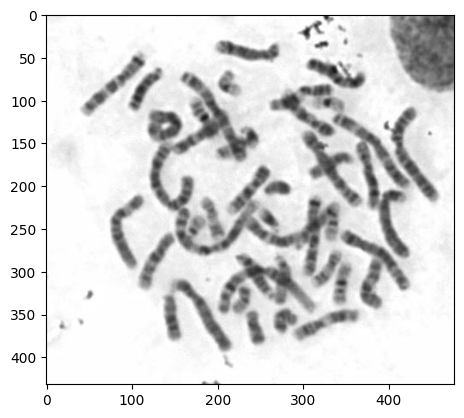

In [2]:
path = Path(RAW_DATA_DIR_IMG)
img_path = next(path.iterdir())
img = cv2.imread(img_path)
plt.imshow(img)

In [3]:
sam_checkpoint = SAM_WEIGHTS
model_type = "vit_h"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
mask_generator1 = SamAutomaticMaskGenerator(sam, points_per_batch=16)
predictor = SamPredictor(sam)

In [4]:
masks = mask_generator1.generate(img)

In [8]:
masks

list

Axes(0.547727,0.11;0.352273x0.77)


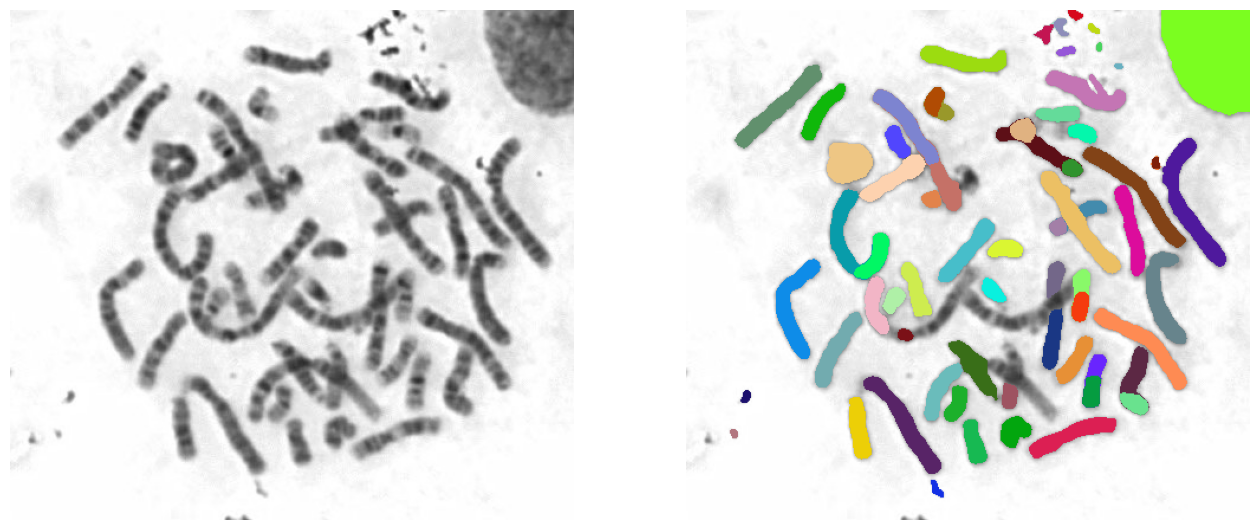

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 16))
axs[0].imshow(img)
axs[1].imshow(img)
show_anns(masks, axs[1])
axs[0].axis('off')
axs[1].axis('off')
plt.show()

In [7]:
img.shape

(432, 477, 3)

In [26]:
path = Path(RAW_DATA_DIR_ANN)
ann_path = next(path.iterdir())
boxes = parse_voc_xml_to_bounding_box(ann_path)
boxes_input = np.array(boxes)
print(boxes_input.shape)

(46, 4)


In [31]:
predictor.set_image(img)
masks, iou_predictions, low_res_masks =  predictor.predict_torch(
    point_coords=None,
    point_labels=None,
    boxes=torch.tensor(boxes_input, dtype=torch.float32).to(predictor.device),
    multimask_output=True,
    mask_input=None,
    return_logits=False
)

KeyboardInterrupt: 